#### Load the necessary libraries

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

#### Defining the Directories

In [2]:
# Set a new working directory
new_directory = r"C:\Users\Chris\Desktop\Solomon"
os.chdir(new_directory)

# Check if the working directory has been changed
current_directory = os.getcwd()
print("New Current Working Directory:", current_directory)

New Current Working Directory: C:\Users\Chris\Desktop\Solomon


#### Loading and displaying the data 

In [5]:
Landsat = rasterio.open(".\LST_Slope_Intercept\Image\Landsat_8_median.tif")
# img0 = show(src.read(1),transform=src.transform, cmap='gray')

# Get the number of bands
num_bands = Landsat.count

print("Number of bands:", num_bands)

data = Landsat.read()

Number of bands: 10


#### Display bands

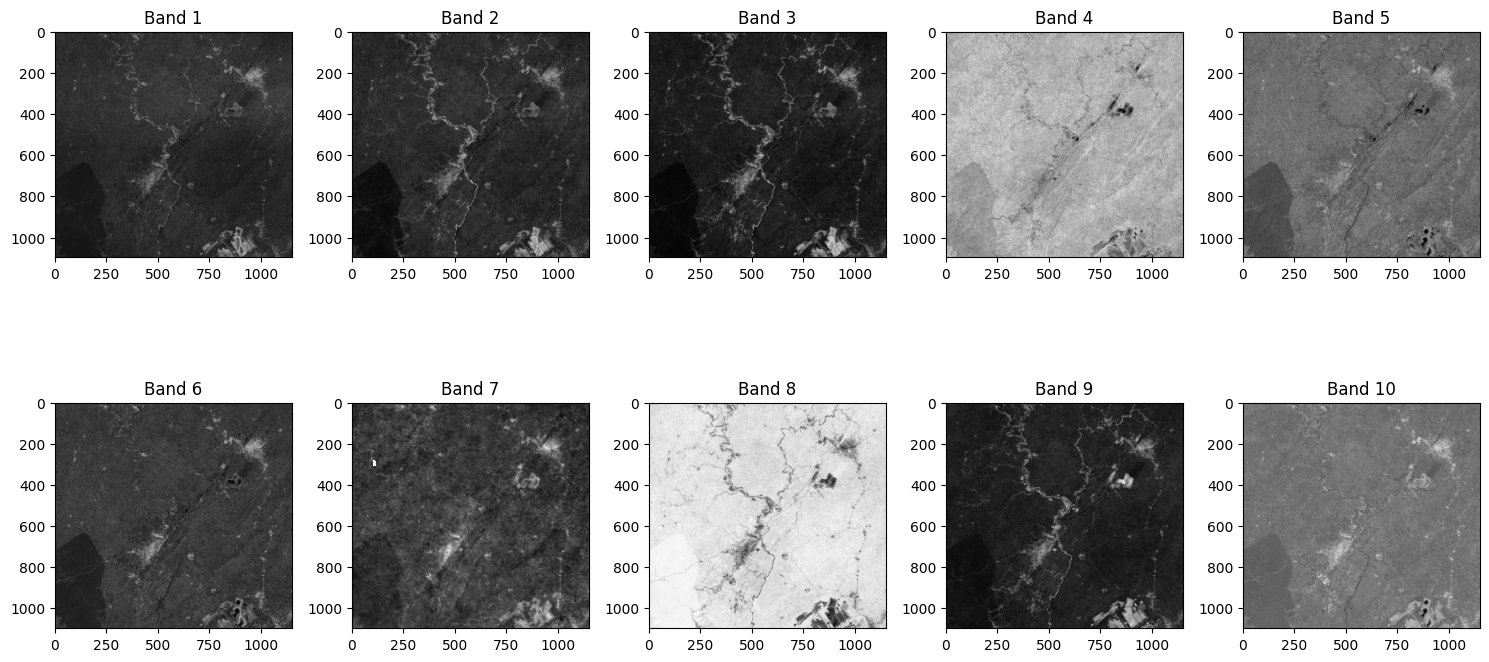

In [4]:
# Display all bands
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
for i in range(1, num_bands + 1):  # Loop through all bands
    ax = axes[(i - 1) // 5, (i - 1) % 5]  # Adjust columns and rows dynamically
    show(Landsat.read(i), ax=ax, cmap='gray')
    ax.set_title(f'Band {i}')
plt.tight_layout()
plt.show()

#### Slope and Intercept

In [6]:
# Select NDVI, NDBI, and NDWI bands (adjust the band indices if needed)
ndvi_band = Landsat.read(8)
ndbi_band = Landsat.read(10)
ndwi_band = Landsat.read(9)

# Flatten bands
ndvi = ndvi_band.flatten()
ndbi = ndbi_band.flatten()
ndwi = ndwi_band.flatten()

# Flatten red band (assuming it's the 4th band, adjust if different)
red_band = Landsat.read(3).flatten()

# Calculate linear regression for NDVI
ndvi = ndvi.reshape(-1, 1)  # Reshape for sklearn
lr_ndvi = LinearRegression()
lr_ndvi.fit(ndvi, red_band)

# Calculate linear regression for NDBI
ndbi = ndbi.reshape(-1, 1)  # Reshape for sklearn
lr_ndbi = LinearRegression()
lr_ndbi.fit(ndbi, red_band)

# Calculate linear regression for NDWI
ndwi = ndwi.reshape(-1, 1)  # Reshape for sklearn
lr_ndwi = LinearRegression()
lr_ndwi.fit(ndwi, red_band)

# Get slopes and intercepts
slope_ndvi = lr_ndvi.coef_[0]
intercept_ndvi = lr_ndvi.intercept_

slope_ndbi = lr_ndbi.coef_[0]
intercept_ndbi = lr_ndbi.intercept_

slope_ndwi = lr_ndwi.coef_[0]
intercept_ndwi = lr_ndwi.intercept_

print("NDVI - Slope:", slope_ndvi, "Intercept:", intercept_ndvi)
print("NDBI - Slope:", slope_ndbi, "Intercept:", intercept_ndbi)
print("NDWI - Slope:", slope_ndwi, "Intercept:", intercept_ndwi)

NDVI - Slope: -0.19841264 Intercept: 0.19776957
NDBI - Slope: 0.26319706 Intercept: 0.122063085
NDWI - Slope: 0.26792455 Intercept: 0.22751278


: 